## Apresentação 4 - Cálculo Numérico
# O ACOPLAMENTO HIDRÁULICO-TÉRMICO
**Grupo 1:** Bruno Lopes de Almeida Zuffo, João Victor Bozola Bosi, Lucas Antero Albuquerque, Matheus Marchi Baron, Natalia Yumi Watanabe, Victor Hugo Albertino e Silva.

---
## 1. Introdução e Parâmetros Iniciais
Modelagem matemática e computacional do acoplamento térmico e fluidodinâmico bidimensional. O escoamento do fluido altera a condutividade térmica efetiva do sólido e atua como sumidouro de calor, enquanto o campo de temperaturas resultante modifica a viscosidade dinâmica do fluido de trabalho, alterando o perfil de pressões da rede hidráulica.

A célula abaixo executa a inicialização dos parâmetros geométricos e físicos, além de resolver o estado isotérmico de referência (a 20°C) para estabelecer a perda de carga inicial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import griddata
import time
import pandas as pd

from functionsHT import (ObterCondutividadeFaces_ViaNos, CriarSistemaSolidoCondutividadeVariavel,
                         calcular_temperatura_media_arestas, calcular_temperatura_media_arestas_ponto_medio,
                         atualiza_condutancias, plot_nos_cromaticos_hidraulica, plot_arestas_cromaticas_hidraulics, 
                         calcular_viscosidade, carregar_rede_hidraulica, calc_campo_fonte ,SolveSystem_FonteEspacial,
                         obter_limites_e_niveis_individuais, plotar_rede_sobre_ax)

from functions import SolveNetwork, calc_vazao, calc_potencia, GeraGrafo, Assembly as AssemblyHidraulico

# -----------------------------------------------------------------------------
# CÓDIGO BASE - define os parâmetros da placa e executa as funções base
# -----------------------------------------------------------------------------

# Parâmetros geométricos da placa
Lx, Ly = 0.03, 0.015
k_0 = 0.25
fonte_calor = 5.0e5
TL, TR = 10.0, 30.0

# Parâmetros da inclusão circular
R_incl = 0.0025
xincl, yincl = 0.02 + R_incl, 0.0075
TC = 35.0

# Parâmetros geométricos e operacionais dos microcanais
Area_canal = 2.5e-7  # 500 um x 500 um
Q_in_0 = 1.0e-7      # 0.1 mL/s (Inlet nó 0)
Q_in_175 = 1.0e-6    # 1.0 mL/s (Inlet nó 175)

# Construção da topologia da rede hidráulica fractal
Xno, conec = GeraGrafo(levels=3)
Xno = Xno * 0.001       # Conversão de mm para metros
Xno[:, 1] += 0.5 * Ly   # Centralização geométrica no eixo Y da placa

# Nós de controle de contorno hidráulico
n_inlet_0 = 0
n_inlet_175 = 175
n_outlet = 5 

# Resolução da hidráulica nominal invariante (Caso Isotérmico de Referência a T = 20°C)
mu_iso = calcular_viscosidade(20.0)
D_h = np.sqrt(4 * Area_canal / np.pi)

C_iso = np.zeros(len(conec))
for k in range(len(conec)):
    Lk = np.linalg.norm(Xno[int(conec[k,1])] - Xno[int(conec[k,0])])
    C_iso[k] = (np.pi * D_h**4) / (128 * mu_iso * Lk)
    
A_h = AssemblyHidraulico(conec, C_iso)
A_h_tilde = A_h.copy()
A_h_tilde[n_outlet, :] = 0.0
A_h_tilde[n_outlet, n_outlet] = 1.0

b_h = np.zeros(len(Xno))
b_h[n_inlet_0] = Q_in_0
b_h[n_inlet_175] = Q_in_175

pressures_iso = np.linalg.solve(A_h_tilde, b_h)
P_max_iso = np.max(pressures_iso)

print("=" * 80)
print("INICIALIZAÇÃO DO ACOMPLAMENTO HIDRÁULICO-TÉRMICO")
print("=" * 80)

print(f"Pressão Máxima Isotérmica Base calculada: {P_max_iso:.2f} Pa\n")

INICIALIZAÇÃO DO ACOMPLAMENTO HIDRÁULICO-TÉRMICO
Pressão Máxima Isotérmica Base calculada: 4045.00 Pa



---
## 2. Formulação Matemática e Estado de Referência Isotérmico (Exercício 1, Seção 4.2.1)

A modelagem do acoplamento hidro-térmico impõe a resolução de dois domínios físicos bidirecionalmente dependentes. A equação diferencial parcial de difusão de calor no chassi bidimensional incorpora a presença física da rede hidráulica por meio de dois mecanismos de alteração topológica: a penalização espacial da condutividade térmica efetiva na grade $k_{i,j}$ (representando a remoção de contato por massa sólida) e a introdução dinâmica de um termo sumidouro estocástico $S_p(x,y,\mathbf{p})$, o qual exaure energia térmica do plano em função da vazão mássica e capacidade térmica local.

No domínio do fluido de trabalho, a conservação da massa ao longo da malha orienta-se pelo sistema matricial de condutâncias hidrostáticas $\mathbf{A}_h(T) \mathbf{p} = \mathbf{b}_h$. Os coeficientes de escoamento são definidos pela restrição da Lei de Poiseuille ($C_k = \frac{\pi D^4}{128 \mu L_k}$). A complexidade matemática origina-se do decaimento não-linear da viscosidade dinâmica do fluido $\mu(T)$ perante a exposição a gradientes de temperatura.

Neste primeiro exercício, suprime-se a dependência cruzada para isolar a termodinâmica. A arquitetura matricial resolve o campo de pressões sob um regime rigorosamente isotérmico (estático a $20^\circ\text{C}$), estabelecendo o teto estrutural de operação nominal da bomba, sem o alívio reológico gerado pela dispersão de calor.

## 3. Análise de Interpolação 2D (Exercício 2, Seção 4.2.1)

A transferência do campo térmico do sólido bidimensional para as coordenadas exatas dos nós da rede hidráulica exige esquemas de mapeamento espacial. Avaliamos três métodos de projeção:

* **Nearest Neighbor (Vizinho Mais Próximo):** Atribuição direta do valor da grade mais próximo. Introduz descontinuidades abruptas e um aspecto "blocado" na solução projetada.
* **Bilinear (Linear):** Interpolação de primeira ordem baseada nos quatro vizinhos mais próximos. Apresenta continuidade básica, suavizando as transições.
* **Bicúbica (Cubic):** Ajuste de terceira ordem sobre uma vizinhança de 16 pontos da grade. Garante a máxima suavidade no campo de temperaturas projetado.

**Impacto da Resolução da Malha:**
A escolha do método se mostrou visualmente irrelevante para a **malha refinada (241x121)**, onde a alta densidade de pontos já garante o mapeamento correto. Porém, para a **malha grosseira (61x31)**, a interpolação Linear ou Bicúbica torna-se estritamente necessária para compensar a baixa resolução espacial e fornecer a temperatura correta ao fluido.

ANÁLISE DE INTERPOLAÇÃO 2D


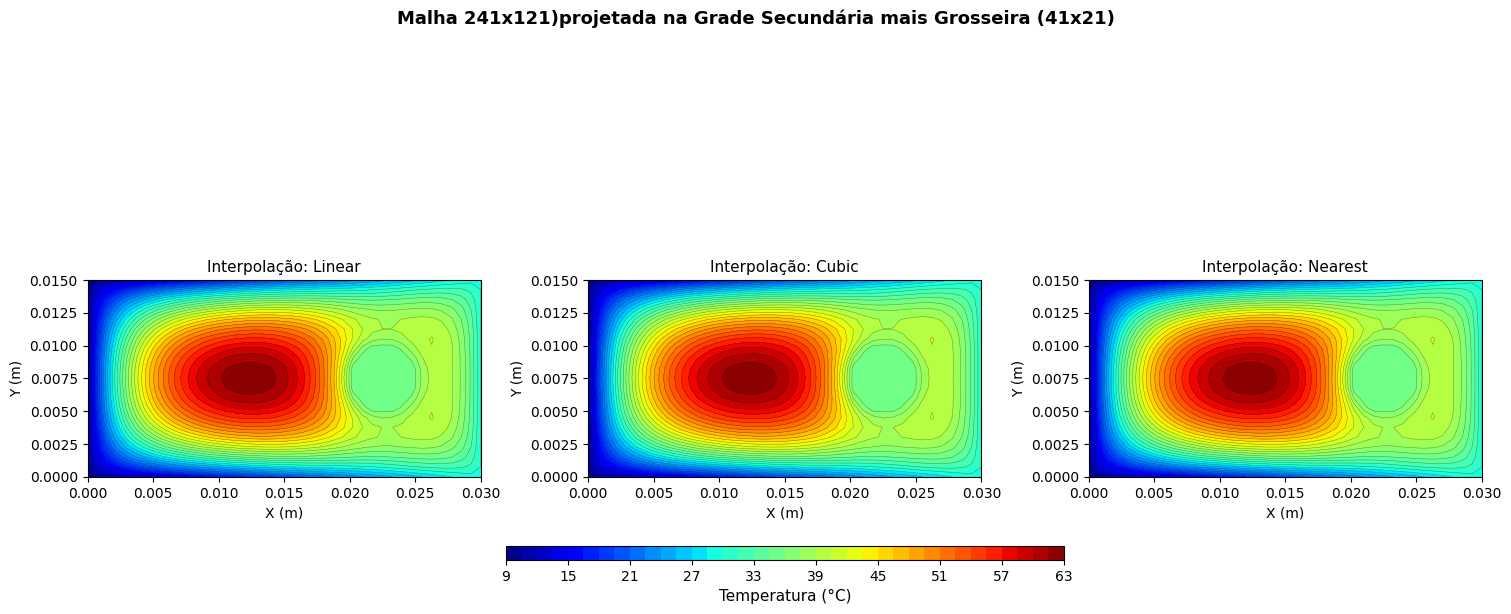

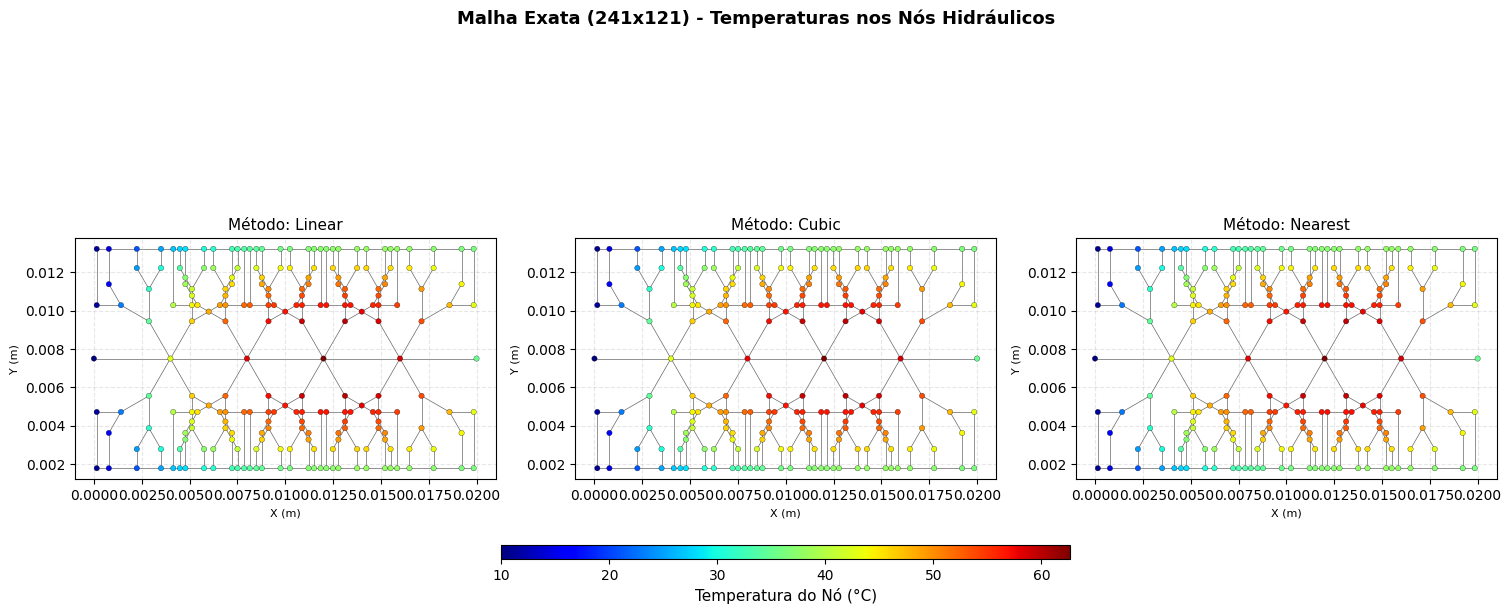

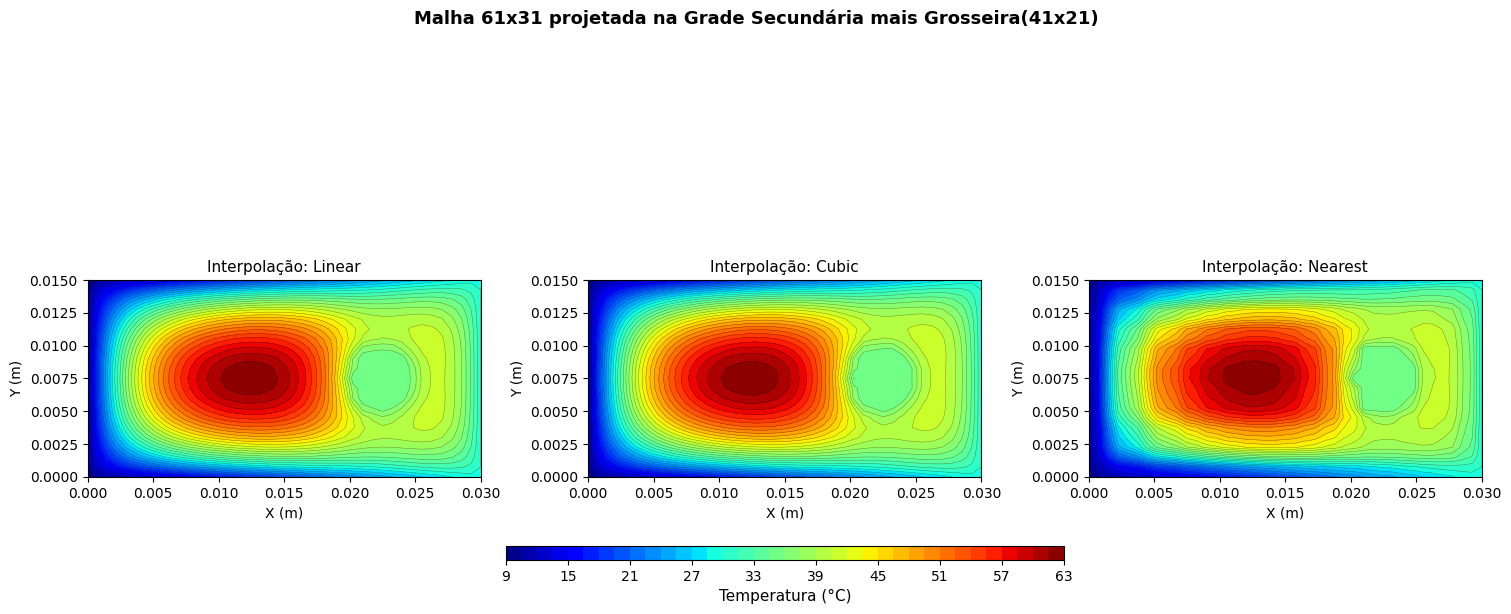

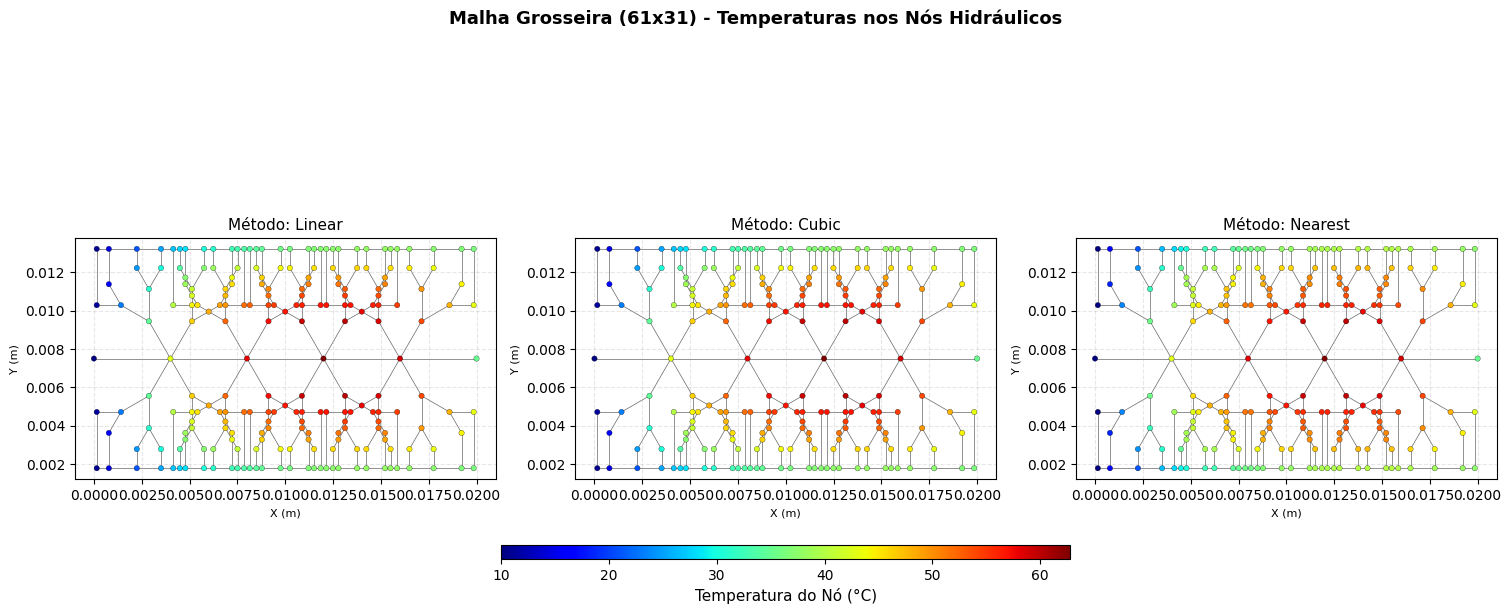

In [4]:
print("=" * 80)
print("ANÁLISE DE INTERPOLAÇÃO 2D")
print("=" * 80)

Xno_base, conec = GeraGrafo(levels=3)
Xno = Xno_base * 0.001 
Xno[:, 1] = Xno[:, 1] + Ly/2  # Ajuste de offset de Y

# DEFINIÇÃO DA MALHA GROSSEIRA EXIGIDA (41 x 321)
Nx_coarse, Ny_coarse = 41, 21  
x_coarse = np.linspace(0, Lx, Nx_coarse)
y_coarse = np.linspace(0, Ly, Ny_coarse)
X_coarse, Y_coarse = np.meshgrid(x_coarse, y_coarse, indexing='ij')
pts_coarse = np.column_stack([X_coarse.ravel(), Y_coarse.ravel()])

métodos = ['linear', 'cubic', 'nearest']

# ---------------------------------------------
# CASO A: Base de Referência com Malha Exata (241 x 121)
# ---------------------------------------------
Nx_ref, Ny_ref = 241, 121
d_max_ref = 0.0005

x_ref_coords = np.linspace(0, Lx, Nx_ref)
y_ref_coords = np.linspace(0, Ly, Ny_ref)
TB_ref = 10.0 + 20.0 * (x_ref_coords / Lx)
TT_ref = 10.0 + 20.0 * (x_ref_coords / Lx)

k_e_ref = np.full((Nx_ref - 1, Ny_ref), k_0)
k_n_ref = np.full((Nx_ref, Ny_ref - 1), k_0)

A_s_ref, b_s_ref = CriarSistemaSolidoCondutividadeVariavel(
    Nx_ref, Ny_ref, Lx, Ly, k_e_ref, k_n_ref, TL, TR, TB_ref, TT_ref, fonte_calor, R_incl, xincl, yincl, TC
)

T_solid_ref = spsolve(sparse.csr_matrix(A_s_ref), b_s_ref)

data_ref = T_solid_ref.reshape((Ny_ref, Nx_ref)).T
T_min_ref, T_max_ref = np.min(T_solid_ref), np.max(T_solid_ref)

figA_cont, axesA_cont = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
figA_cont.suptitle("Malha 241x121)projetada na Grade Secundária mais Grosseira (41x21)", fontweight='bold', fontsize=13)

figA_graf, axesA_graf = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
figA_graf.suptitle("Malha Exata (241x121) - Temperaturas nos Nós Hidráulicos", fontweight='bold', fontsize=13)

for idx, método in enumerate(métodos):
    interp_ref = RegularGridInterpolator((x_ref_coords, y_ref_coords), data_ref, method=método, bounds_error=False, fill_value=None)
    
    # 1. Contorno
    temps_coarse = interp_ref(pts_coarse).reshape(Nx_coarse, Ny_coarse)
    temps_coarse = np.clip(temps_coarse, T_min_ref, T_max_ref)
    
    cp = axesA_cont[idx].contourf(x_coarse, y_coarse, temps_coarse.T, levels=40, cmap='jet')
    axesA_cont[idx].contour(x_coarse, y_coarse, temps_coarse.T, levels=40, colors='black', linewidths=0.3, alpha=0.5)
    axesA_cont[idx].set_title(f"Interpolação: {método.capitalize()}", fontsize=11)
    axesA_cont[idx].set_xlabel("X (m)")
    axesA_cont[idx].set_ylabel("Y (m)")
    axesA_cont[idx].set_aspect('equal')
    
    # 2. Grafo Nodal
    T_nodes_hyd_ref = interp_ref(Xno)
    T_nodes_hyd_ref = np.clip(T_nodes_hyd_ref, T_min_ref, T_max_ref)
    
    sc = plot_nos_cromaticos_hidraulica(conec, Xno, T_nodes_hyd_ref, método, Nx_ref, Ny_ref, ax=axesA_graf[idx])
    axesA_graf[idx].set_title(f"Método: {método.capitalize()}", fontsize=11)
    axesA_graf[idx].set_aspect('equal')

cbarA_cont = figA_cont.colorbar(cp, ax=axesA_cont.ravel().tolist(), orientation='horizontal', shrink=0.4, aspect=40)
cbarA_cont.set_label('Temperatura (°C)', fontsize=11)

cbarA_graf = figA_graf.colorbar(sc, ax=axesA_graf.ravel().tolist(), orientation='horizontal', shrink=0.4, aspect=40)
cbarA_graf.set_label('Temperatura do Nó (°C)', fontsize=11)

plt.show()

# ---------------------------------------------------
# CASO B: Solução Base com Malha Grosseira (61 x 31)
# ---------------------------------------------------

Nx_61, Ny_61 = 61, 31
d_max_61 = 0.0005

x_61_coords = np.linspace(0, Lx, Nx_61)
y_61_coords = np.linspace(0, Ly, Ny_61)
TB_61 = 10.0 + 20.0 * (x_61_coords / Lx)
TT_61 = 10.0 + 20.0 * (x_61_coords / Lx)

k_e_61 = np.full((Nx_61 - 1, Ny_61), k_0)
k_n_61 = np.full((Nx_61, Ny_61 - 1), k_0)

A_s_61, b_s_61 = CriarSistemaSolidoCondutividadeVariavel(
    Nx_61, Ny_61, Lx, Ly, k_e_61, k_n_61, TL, TR, TB_61, TT_61, fonte_calor, R_incl, xincl, yincl, TC
)
T_solid_61 = spsolve(sparse.csr_matrix(A_s_61), b_s_61)

data_61 = T_solid_61.reshape((Ny_61, Nx_61)).T
T_min_61, T_max_61 = np.min(T_solid_61), np.max(T_solid_61)

figB_cont, axesB_cont = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
figB_cont.suptitle("Malha 61x31 projetada na Grade Secundária mais Grosseira(41x21)", fontweight='bold', fontsize=13)

figB_graf, axesB_graf = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
figB_graf.suptitle("Malha Grosseira (61x31) - Temperaturas nos Nós Hidráulicos", fontweight='bold', fontsize=13)

for idx, método in enumerate(métodos):
    interp_61 = RegularGridInterpolator((x_61_coords, y_61_coords), data_61, method=método, bounds_error=False, fill_value=None)
    
    # 1. Contorno
    temps_coarse_61 = interp_61(pts_coarse).reshape(Nx_coarse, Ny_coarse)
    temps_coarse_61 = np.clip(temps_coarse_61, T_min_61, T_max_61)
    
    cp61 = axesB_cont[idx].contourf(x_coarse, y_coarse, temps_coarse_61.T, levels=40, cmap='jet')
    axesB_cont[idx].contour(x_coarse, y_coarse, temps_coarse_61.T, levels=40, colors='black', linewidths=0.3, alpha=0.5)
    axesB_cont[idx].set_title(f"Interpolação: {método.capitalize()}", fontsize=11)
    axesB_cont[idx].set_xlabel("X (m)")
    axesB_cont[idx].set_ylabel("Y (m)")
    axesB_cont[idx].set_aspect('equal')
    
    # 2. Grafo Nodal
    T_nodes_hyd_61 = interp_61(Xno)
    T_nodes_hyd_61 = np.clip(T_nodes_hyd_61, T_min_61, T_max_61)
    
    sc61 = plot_nos_cromaticos_hidraulica(conec, Xno, T_nodes_hyd_61, método, Nx_61, Ny_61, ax=axesB_graf[idx])
    axesB_graf[idx].set_title(f"Método: {método.capitalize()}", fontsize=11)
    axesB_graf[idx].set_aspect('equal')

cbarB_cont = figB_cont.colorbar(cp61, ax=axesB_cont.ravel().tolist(), orientation='horizontal', shrink=0.4, aspect=40)
cbarB_cont.set_label('Temperatura (°C)', fontsize=11)

cbarB_graf = figB_graf.colorbar(sc61, ax=axesB_graf.ravel().tolist(), orientation='horizontal', shrink=0.4, aspect=40)
cbarB_graf.set_label('Temperatura do Nó (°C)', fontsize=11)

plt.show()

---
## 4. Acoplamento Hidro-Térmico no Grafo (Exercício 3, Seção 4.2.1)

A temperatura média de escoamento ao longo de cada trecho linear (aresta $k$) é mapeada por meio de integração unidimensional parametrizada pelo comprimento $L_k$ da tubulação:

$$\bar{T}_k = \frac{1}{L_k} \int_{0}^{L_k} T(s) \, ds$$

Avaliamos o desempenho e a convergência do cálculo com o refinamento do número de partições espaciais $N$ sob duas formulações de quadratura:
* **Regra dos Trapézios:** Aproximação polinomial linear segmentada com base nas extremidades de cada partição. Erro de truncamento governado por $\mathcal{O}(\Delta s^2)$.
* **Regra do Ponto Médio:** Avaliação do integrando restrita ao centro geométrico de cada intervalo. Possui erro assintótico da mesma ordem $\mathcal{O}(\Delta s^2)$, mas minimiza operações de ponto flutuante por reduzir o número total de chamadas ao interpolador.


ACOPLAMENTO HIDRO-TÉRMICO NO GRAFO

-----------------------------------------------------------------------------------------------
 TABELA 1: RESULTADOS NUMÉRICOS E ESTIMATIVA DE ERRO (|T_N - T_1000|)
-----------------------------------------------------------------------------------------------
N      | T_Média (Trapézio)   | Erro (Trapézio) | T_Média (Ponto Médio)  | Erro (Ponto Médio)
-----------------------------------------------------------------------------------------------
1      | 32.793983            | 4.71e-02        | 32.868176              | 2.71e-02
10     | 32.840637            | 4.61e-04        | 32.841384              | 2.86e-04
100    | 32.841093            | 4.41e-06        | 32.841100              | 2.19e-06
1000   | 32.841098            | 0.00e+00        | 32.841098              | 6.04e-08
-----------------------------------------------------------------------------------------------

------------------------------------------------------------
 TABELA 2: COMPAR

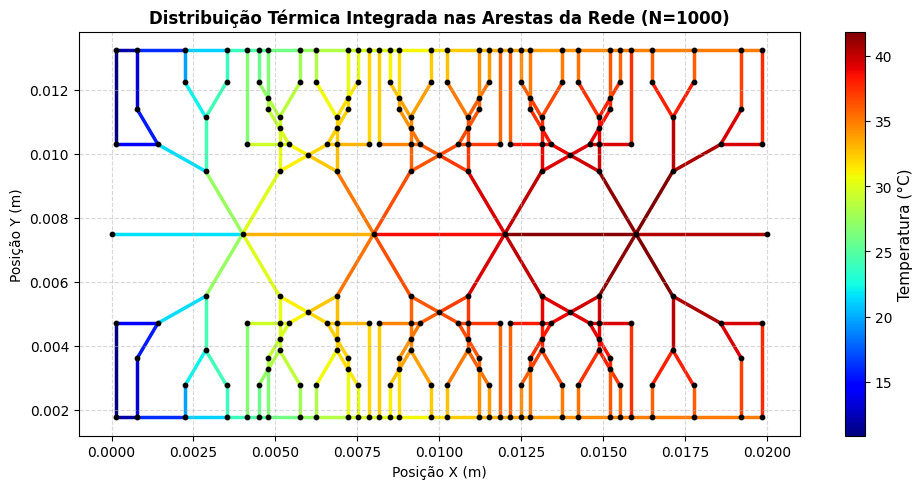

In [15]:
print("\n" + "=" * 80)
print("ACOPLAMENTO HIDRO-TÉRMICO NO GRAFO")
print("=" * 80)

subintervalos = [1, 10, 100, 1000]
resultados = []
T_arestas_final = None

for N in subintervalos:
    # 1. Trapézio (Utiliza a função nativa que já está no seu functionsHT.py)
    T_trap, t_trap = calcular_temperatura_media_arestas(
        conec, Xno, T_solid_ref, int(Nx_ref), int(Ny_ref), Lx, Ly, num_subintervalos=N
    )
    
    # 2. Ponto Médio (Utiliza a função definida acima)
    T_mid, t_mid = calcular_temperatura_media_arestas_ponto_medio(
        conec, Xno, T_solid_ref, int(Nx_ref), int(Ny_ref), Lx, Ly, num_subintervalos=N
    )
    
    resultados.append({
        'N': N,
        'T_trap': np.mean(T_trap),
        'T_mid': np.mean(T_mid),
        't_trap': t_trap,
        't_mid': t_mid
    })
    
    # Adota N=1000 do Trapézio como modelo físico consolidado para prosseguir
    if N == 1000:
        T_arestas_final = T_trap  

# Assume a discretização máxima (N=1000) como solução de referência "exata"
T_ref = resultados[-1]['T_trap']

# --- IMPRESSÃO DA TABELA 1: RESULTADOS NUMÉRICOS E ESTIMATIVA DE ERRO ---
print("\n" + "-" * 95)
print(" TABELA 1: RESULTADOS NUMÉRICOS E ESTIMATIVA DE ERRO (|T_N - T_1000|)")
print("-" * 95)
print(f"{'N':<6} | {'T_Média (Trapézio)':<20} | {'Erro (Trapézio)':<15} | {'T_Média (Ponto Médio)':<22} | {'Erro (Ponto Médio)'}")
print("-" * 95)
for res in resultados:
    erro_trap = abs(res['T_trap'] - T_ref)
    erro_mid = abs(res['T_mid'] - T_ref)
    print(f"{res['N']:<6} | {res['T_trap']:<18.6f}   | {erro_trap:<15.2e} | {res['T_mid']:<20.6f}   | {erro_mid:.2e}")
print("-" * 95)

# --- IMPRESSÃO DA TABELA 2: TEMPO COMPUTACIONAL ---
print("\n" + "-" * 60)
print(" TABELA 2: COMPARAÇÃO DO TEMPO COMPUTACIONAL (s)")
print("-" * 60)
print(f"{'N':<6} | {'Tempo Trapézio (s)':<20} | {'Tempo Ponto Médio (s)'}")
print("-" * 60)
for res in resultados:
    print(f"{res['N']:<6} | {res['t_trap']:<20.4e} | {res['t_mid']:.4e}")
print("-" * 60 + "\n")

C_acoplado = atualiza_condutancias(conec, Xno, T_arestas_final, Area_canal)

A_h_mod = AssemblyHidraulico(conec, C_acoplado)
A_h_mod_tilde = A_h_mod.copy()

# Aplica as condições de contorno de saída
A_h_mod_tilde[n_outlet, :] = 0.0
A_h_mod_tilde[n_outlet, n_outlet] = 1.0

pressures_mod = np.linalg.solve(A_h_mod_tilde, b_h)
P_max_mod = np.max(pressures_mod)

print("-" * 80)
print(f"Pressão Máxima (Isotérmica):          {P_max_iso:.2f} Pa")
print(f"Pressão Máxima (Acoplada Corrigida):  {P_max_mod:.2f} Pa")
print(f"Variação da Perda de Carga Realizada: {((P_max_mod - P_max_iso)/P_max_iso)*100:.2f}%")
print("-" * 80)

# Renderização dos perfis de controle térmico do fluido
plot_arestas_cromaticas_hidraulics(conec, Xno, T_arestas_final, titulo="Distribuição Térmica Integrada nas Arestas da Rede (N=1000)")

---
## 5. Rede Hidráulica com C(T) (Exercício 4, Seção 4.2.1)

Análise integrada do acoplamento completo, avaliando o comportamento das grandezas de fluxo frente à variação conjunta da discretização espacial do domínio térmico sólido e das regras de quadratura unidimensional.

O aquecimento global e local reduz exponencialmente a viscosidade reológica do fluido. Esse fenômeno gera uma elevação proporcional nas condutâncias hidráulicas locais da rede, aliviando a perda de carga total e reduzindo a potência viscosa total dissipada ($W = \mathbf{p}^T \mathbf{A}_h \mathbf{p}$) exigida pela bomba.


EXERCÍCIO 4 - CAPÍTULO 4: REDE HIDRÁULICA COM C(T)

--- Resolvendo campo térmico na malha 61 x 31 ---

--- Resolvendo campo térmico na malha 241 x 121 ---

 TABELA DE RESULTADOS FÍSICOS (TEMPERATURAS E PRESSÃO)
Malha      | Método       | N     | T_Min (°C)   | T_Média (°C) | T_Max (°C)   | P_Max (Pa)
-------------------------------------------------------------------------------------
61x31      | ponto_medio  | 1     | 11.2644      | 44.0231      | 62.1108      | 2606.54
61x31      | ponto_medio  | 10    | 11.2426      | 43.9408      | 61.8222      | 2634.39
61x31      | ponto_medio  | 100   | 11.2423      | 43.9399      | 61.8199      | 2634.78
61x31      | ponto_medio  | 1000  | 11.2423      | 43.9399      | 61.8199      | 2634.78
61x31      | trapezio     | 1     | 11.1950      | 43.7704      | 61.3395      | 2700.79
61x31      | trapezio     | 10    | 11.2417      | 43.9381      | 61.8154      | 2635.48
61x31      | trapezio     | 100   | 11.2423      | 43.9399      | 61.8198   

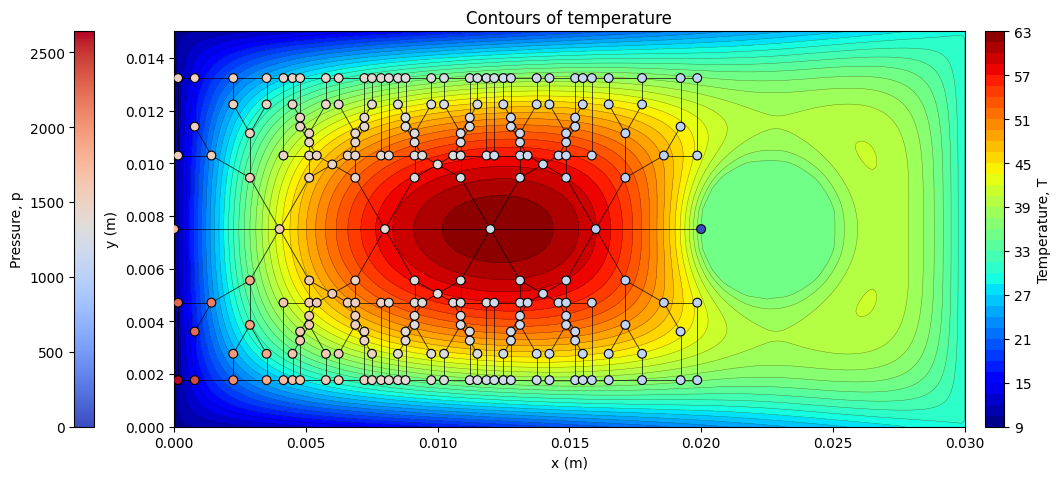

In [12]:
print("\n" + "="*75)
print("EXERCÍCIO 4 - CAPÍTULO 4: REDE HIDRÁULICA COM C(T)")
print("="*75)
# Importações estritamente dos arquivos de funções (Sem duplicidades)
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable
from functionsHT import CriarSistemaSolidoCondutividadeVariavel, atualiza_condutancias
from functions import SolveNetwork, calc_potencia, GeraGrafo
# Parâmetros Geométricos e Físicos Locais do Exercício 4
Lx_ex4, Ly_ex4 = 0.03, 0.015
k_0_ex4 = 0.25
fonte_calor_ex4 = 5.0e5
TL_ex4, TR_ex4 = 10.0, 30.0
R_incl_ex4 = 0.0025
xincl_ex4, yincl_ex4 = 0.02 + R_incl_ex4, 0.0075
TC_ex4 = 35.0
Area_canal_ex4 = 2.5e-7
# Construção da Rede Hidráulica Isolada do Exercício 4
Xno_ex4, conec_ex4 = GeraGrafo(levels=3)
Xno_ex4 = Xno_ex4 * 0.001
Xno_ex4[:, 1] += 0.5 * Ly_ex4  # Centraliza a rede em Y dentro da placa
# Condições de contorno da rede hidráulica (Mapeamento via strings)
ps_hid_ex4 = {"6": 0.0}
Qs_hid_ex4 = {"1": 1.0e-7, "176": 1.0e-6}
lista_malhas_termicas = [(61, 31), (241, 121)]
lista_metodos = ["ponto_medio", "trapezio"]
lista_subintervalos = [1, 10, 100, 1000]
resultados_ex4 = []
T_arestas_final_ex4 = None  
interpolador_final_ex4 = None
# Loop de Varredura das Malhas, Métodos e Subintervalos
for Nx, Ny in lista_malhas_termicas:
    print(f"\n--- Resolvendo campo térmico na malha {Nx} x {Ny} ---")
    x_coords = np.linspace(0.0, Lx_ex4, Nx)
    y_coords = np.linspace(0.0, Ly_ex4, Ny)
    TB = 10.0 + 20.0 * (x_coords / Lx_ex4)
    TT = 10.0 + 20.0 * (x_coords / Lx_ex4)
    k_e = np.ones((Nx - 1, Ny)) * k_0_ex4
    k_n = np.ones((Nx, Ny - 1)) * k_0_ex4
    # Montagem e resolução térmica usando as funções originais
    A_T, b_T = CriarSistemaSolidoCondutividadeVariavel(
        Nx, Ny, Lx_ex4, Ly_ex4, k_e, k_n, TL_ex4, TR_ex4, TB, TT, 
        fonte_calor_ex4, R_incl_ex4, xincl_ex4, yincl_ex4, TC_ex4
    )
    T_flat_ex4 = spsolve(sparse.csr_matrix(A_T), b_T)
    # Construção do Interpolador usando a função padrão da biblioteca
    T_matriz_interp = T_flat_ex4.reshape((Ny, Nx)).T
    interpolador_T = RegularGridInterpolator((x_coords, y_coords), T_matriz_interp, method="linear", bounds_error=False, fill_value=np.nan)
    for metodo in lista_metodos:
        for nsub in lista_subintervalos:
            # 1. Cálculo da Temperatura média nas arestas
            T_arestas = np.zeros(len(conec_ex4))
            for k in range(len(conec_ex4)):
                p1, p2 = Xno_ex4[int(conec_ex4[k, 0])], Xno_ex4[int(conec_ex4[k, 1])]
                if metodo == "trapezio":
                    s = np.linspace(0, 1, nsub + 1)
                    pts = p1 + np.outer(s, p2 - p1)
                    T_arestas[k] = np.trapezoid(interpolador_T(pts), x=s)
                elif metodo == "ponto_medio":
                    s = np.linspace(0.5 / nsub, 1 - 0.5 / nsub, nsub)
                    pts = p1 + np.outer(s, p2 - p1)
                    T_arestas[k] = np.mean(interpolador_T(pts))
            # Guarda o estado da malha mais refinada para compor o gráfico final
            if Nx == 241 and metodo == "trapezio" and nsub == 1000:
                T_arestas_final_ex4 = T_arestas.copy()
                interpolador_final_ex4 = interpolador_T
                pressure_final_ex4 = pressure_T.copy()
                T_matriz_final_ex4 = T_flat_ex4.reshape((Ny, Nx)).copy()
            # 2. Atualização das condutâncias hidráulicas baseadas em T_arestas
            C_T = atualiza_condutancias(conec_ex4, Xno_ex4, T_arestas, Area_canal_ex4)
            # 3. Solução do escoamento na rede hidráulica
            pressure_T = SolveNetwork(conec_ex4, C_T, ps=ps_hid_ex4, Qs=Qs_hid_ex4)
            # 4. Cálculo da Potência dissipada
            W_T = calc_potencia(conec_ex4, C_T, pressure_T)
            resultados_ex4.append({
                "malha_termica": f"{Nx}x{Ny}",
                "metodo_quadratura": metodo,
                "nsub": nsub,
                "T_aresta_min": np.min(T_arestas),
                "T_aresta_media": np.mean(T_arestas),
                "T_aresta_max": np.max(T_arestas),
                "pressao_max": np.max(pressure_T),
                "pressao_min": np.min(pressure_T),
                "potencia_total": W_T
            })
# Backup de contingência
if T_arestas_final_ex4 is None:
    T_arestas_final_ex4 = T_arestas.copy()
    interpolador_final_ex4 = interpolador_T
    pressure_final_ex4 = pressure_T.copy()
    T_matriz_final_ex4 = T_flat_ex4.reshape((Ny, Nx)).copy()
# ---------------------------------------------------------------------
# Geração das Tabelas ASCII Formatadas
# ---------------------------------------------------------------------
df_ex4 = pd.DataFrame(resultados_ex4)
print("\n" + "="*85)
print(" TABELA DE RESULTADOS FÍSICOS (TEMPERATURAS E PRESSÃO)")
print("="*85)
print(f"{'Malha':<10} | {'Método':<12} | {'N':<5} | {'T_Min (°C)':<12} | {'T_Média (°C)':<12} | {'T_Max (°C)':<12} | {'P_Max (Pa)'}")
print("-" * 85)
for res in resultados_ex4:
    print(f"{res['malha_termica']:<10} | {res['metodo_quadratura']:<12} | {res['nsub']:<5} | "
          f"{res['T_aresta_min']:<12.4f} | {res['T_aresta_media']:<12.4f} | {res['T_aresta_max']:<12.4f} | {res['pressao_max']:.2f}")
print("-" * 85)
# ---------------------------------------------------------------------
# PLOTAGEM ACOPLADA: FUNDO (TEMPERATURA) + NÓS (PRESSÃO)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Contorno de Temperatura (Fundo)
x_coords_plot = np.linspace(0.0, Lx_ex4, 241)
y_coords_plot = np.linspace(0.0, Ly_ex4, 121)
X_grid, Y_grid = np.meshgrid(x_coords_plot, y_coords_plot)

# Plota o preenchimento de contorno termodinâmico
cont = ax.contourf(X_grid, Y_grid, T_matriz_final_ex4, levels=40, cmap='jet')
ax.contour(X_grid, Y_grid, T_matriz_final_ex4, levels=40, colors='black', linewidths=0.3, alpha=0.5)

# 2. Arestas da Rede (Linhas Pretas Direcionais)
for k in range(len(conec_ex4)):
    n1, n2 = int(conec_ex4[k, 0]), int(conec_ex4[k, 1])
    ax.plot([Xno_ex4[n1, 0], Xno_ex4[n2, 0]], [Xno_ex4[n1, 1], Xno_ex4[n2, 1]], 
            color='black', linewidth=0.6, zorder=2, alpha=0.8)

# 3. Nós da Rede (Coloridos pela Pressão)
sc = ax.scatter(
    Xno_ex4[:, 0], Xno_ex4[:, 1],
    c=pressure_final_ex4,
    cmap='coolwarm', 
    s=40,
    zorder=3,
    edgecolors='black',
    linewidths=0.8
)

# Estilização Geométrica e Travamento de Escala
ax.set_title("Contours of temperature", fontsize=12)
ax.set_xlabel('x (m)', fontsize=10)
ax.set_ylabel('y (m)', fontsize=10)
ax.set_xlim(0, Lx_ex4)
ax.set_ylim(0, Ly_ex4)
ax.set_aspect('equal')

# 4. Alocação Estrita das Barras de Cores (Desacoplamento)
divider = make_axes_locatable(ax)

# Barra Esquerda (Pressão)
cax_P = divider.append_axes("left", size="2.5%", pad=0.8)
cbar_P = fig.colorbar(sc, cax=cax_P)
cax_P.yaxis.set_ticks_position('left')
cax_P.yaxis.set_label_position('left')
cbar_P.set_label('Pressure, p', fontsize=10)

# Barra Direita (Temperatura)
cax_T = divider.append_axes("right", size="2.5%", pad=0.2)
cbar_T = fig.colorbar(cont, cax=cax_T)
cbar_T.set_label('Temperature, T', fontsize=10)

plt.show()


---
## 6. Método alternativo para calcular viscosidade (Exercício 5, Seção 4.2.1)

No capítulo, a abordagem padrão calcula a viscosidade da temperatura média.
$$\langle T_k \rangle = \frac{1}{\ell_k} \int_{0}^{\ell_k} T_k (\mathbf{p}(s)) \, ds$$
$$\mu_k \approx \mu (\langle T_k \rangle)$$


Nota-se que o capítulo define a viscosidade do fluído, a qual é não-linear:

$$\mu(T) = \frac{0.001791}{1 + 0.03368T + 0.000221T^2}$$

Logo, a alternativa seria integrar a própria função de viscosidade ao longo da aresta:

$$\langle \mu_k \rangle = \frac{1}{l_k} \int_{0}^{l_k} \mu(T_k(p(s))) \, ds$$


---
## 7. Condutividade Modificada por Proximidade (Exercício 1, Seção 4.3.3)

A presença física da rede induz variações na condutividade térmica efetiva do sólido. Modificam-se os coeficientes locais ($k_e$ e $k_n$) avaliados nas interfaces dos volumes finitos com base na distância euclidiana mínima $d$ em relação aos filamentos mais próximos.

Para contornar o custo computacional imposto por uma busca exaustiva $\mathcal{O}(N_{\text{grade}} \times N_{\text{arestas}})$, estrutura-se o mapeamento topológico por meio de uma árvore de partição binária ortogonal k-dimensional (**`cKDTree`**). O algoritmo atenua a complexidade assintótica para a escala $\mathcal{O}(N \log N)$, viabilizando a varredura paramétrica de refinamento de malha em tempo de execução.


CONDUTIVIDADE MODIFICADA POR PROXIMIDADE

------------------------------------------------------------
Executando Refinamento Espacial: Malha 61 x 31
------------------------------------------------------------
 -> Calculando cenário para d_max = 0.00025 m...


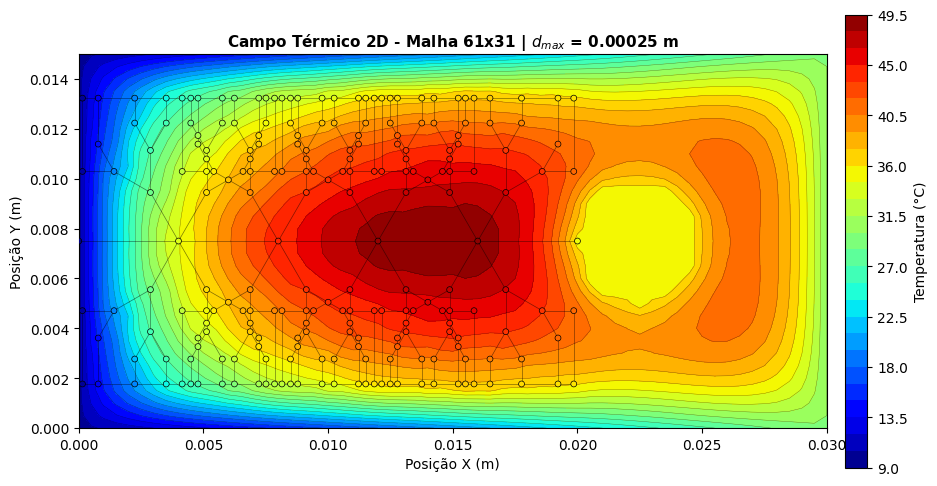

 -> Calculando cenário para d_max = 0.0005 m...


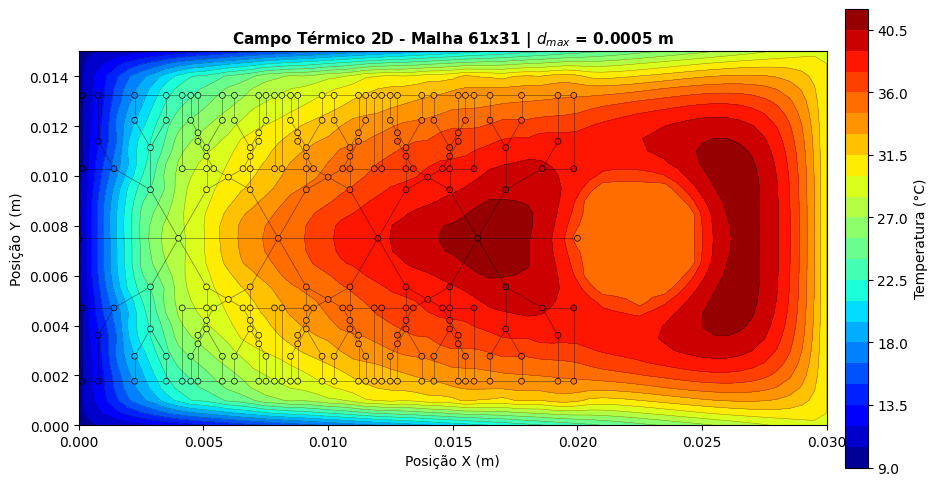

 -> Calculando cenário para d_max = 0.001 m...


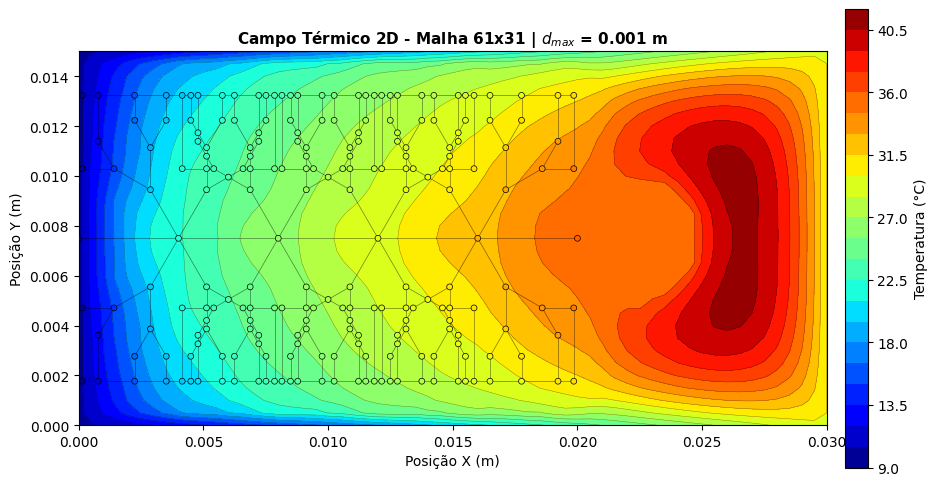

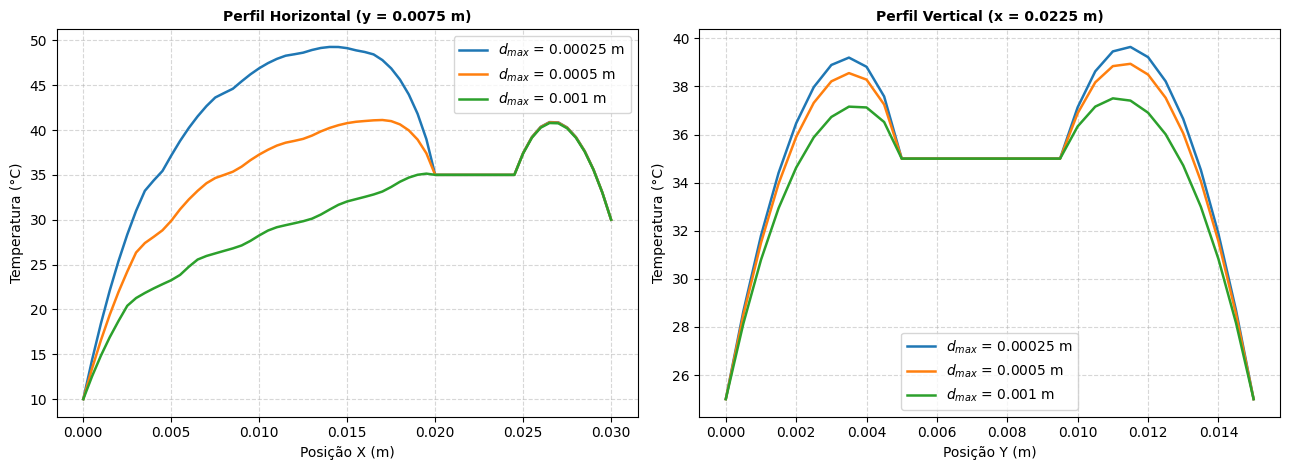


------------------------------------------------------------
Executando Refinamento Espacial: Malha 121 x 61
------------------------------------------------------------
 -> Calculando cenário para d_max = 0.00025 m...


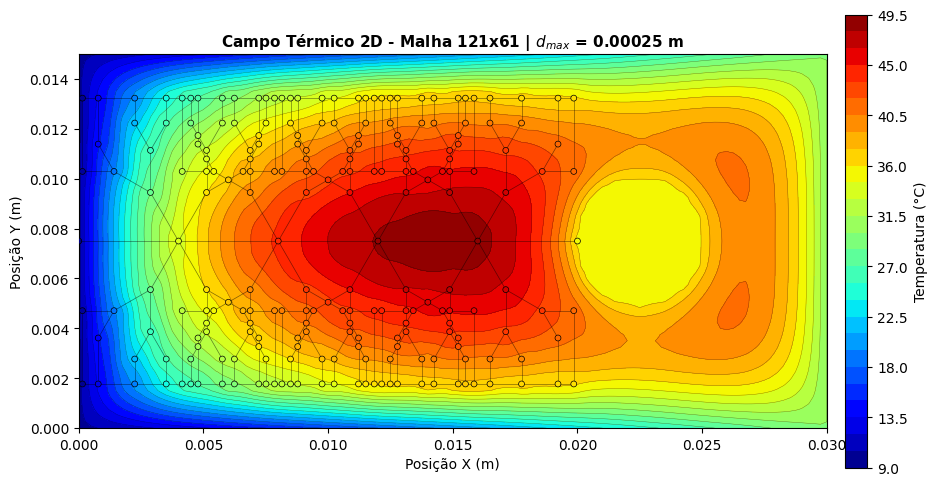

 -> Calculando cenário para d_max = 0.0005 m...


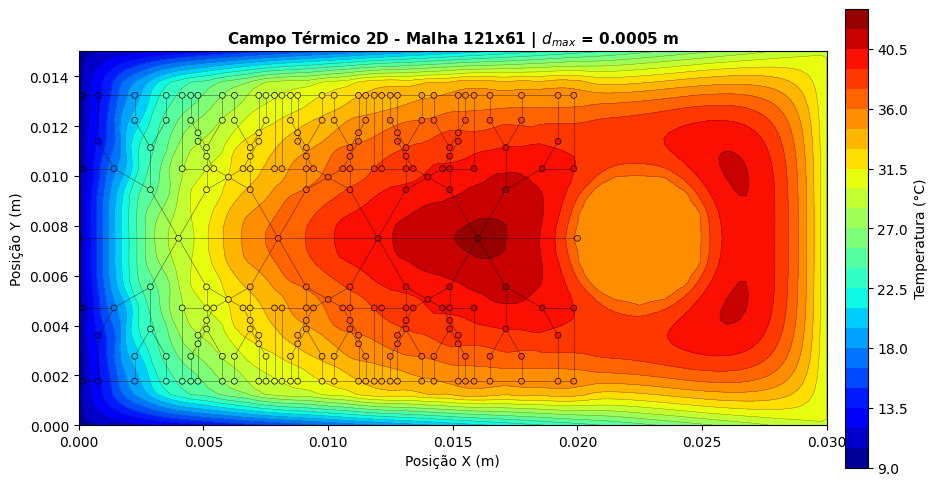

 -> Calculando cenário para d_max = 0.001 m...


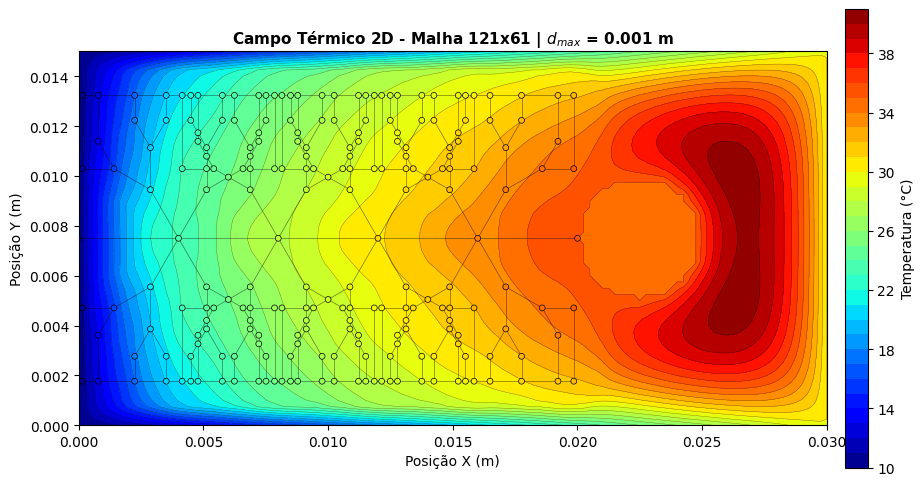

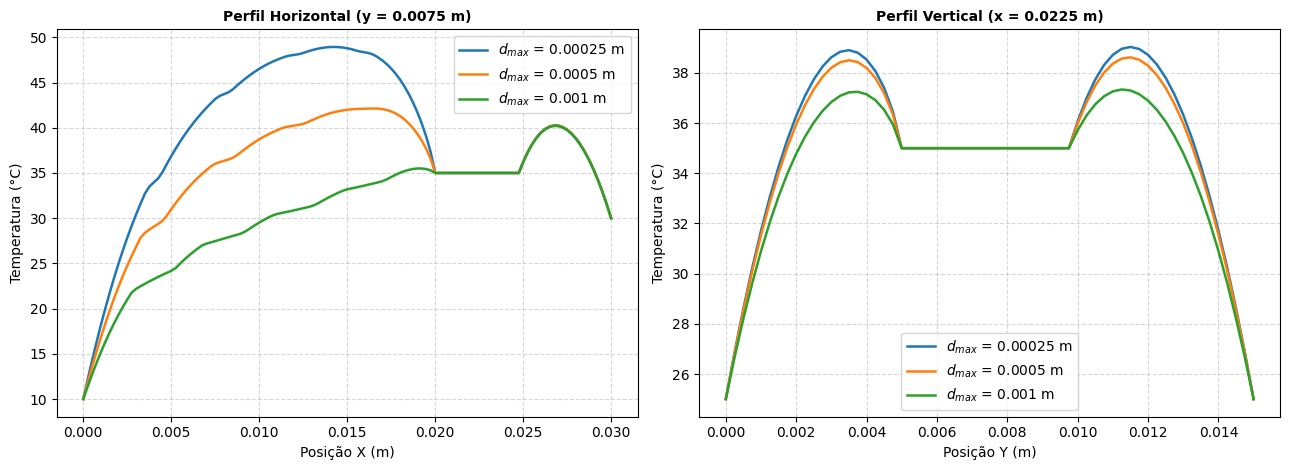


------------------------------------------------------------
Executando Refinamento Espacial: Malha 241 x 121
------------------------------------------------------------
 -> Calculando cenário para d_max = 0.00025 m...


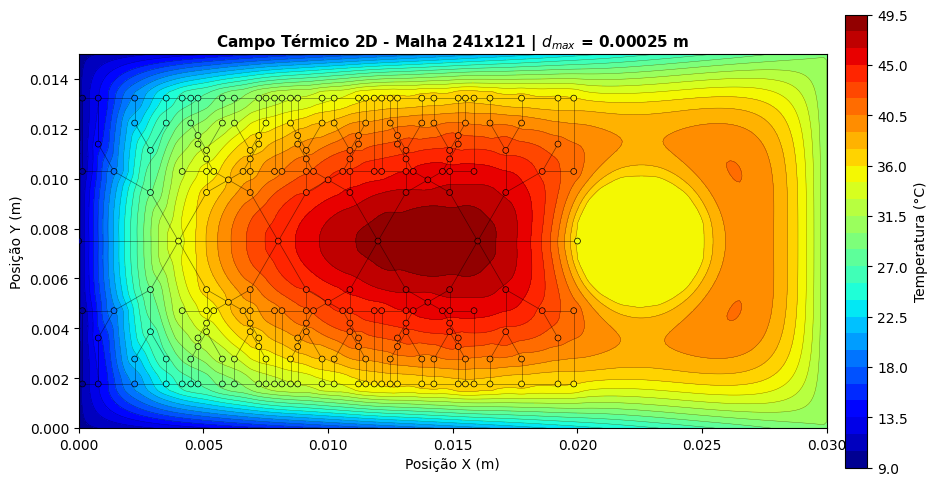

 -> Calculando cenário para d_max = 0.0005 m...


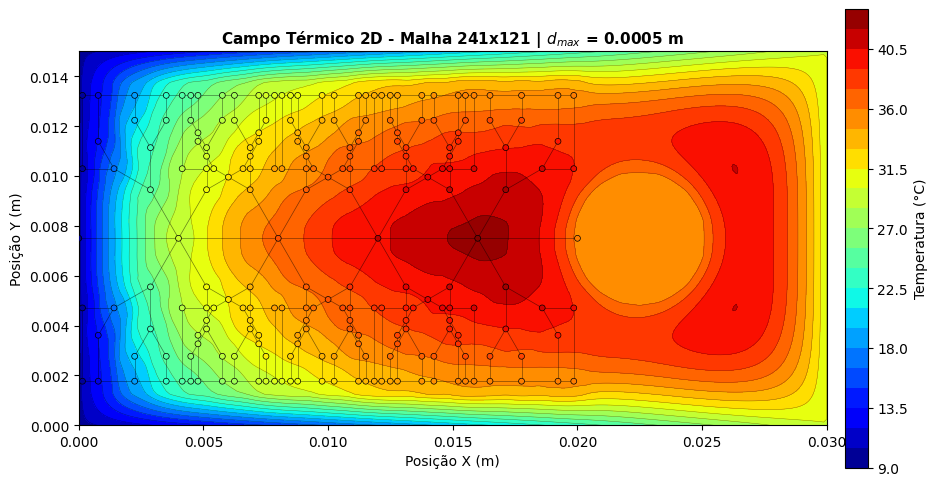

 -> Calculando cenário para d_max = 0.001 m...


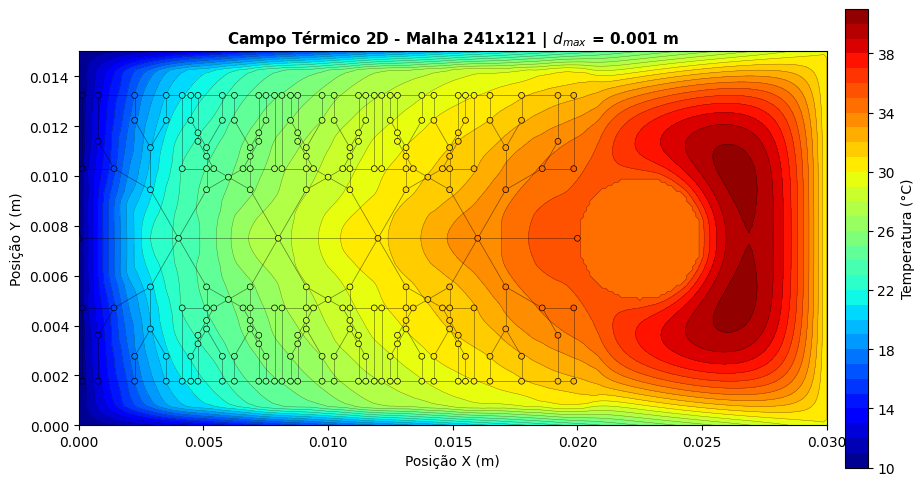

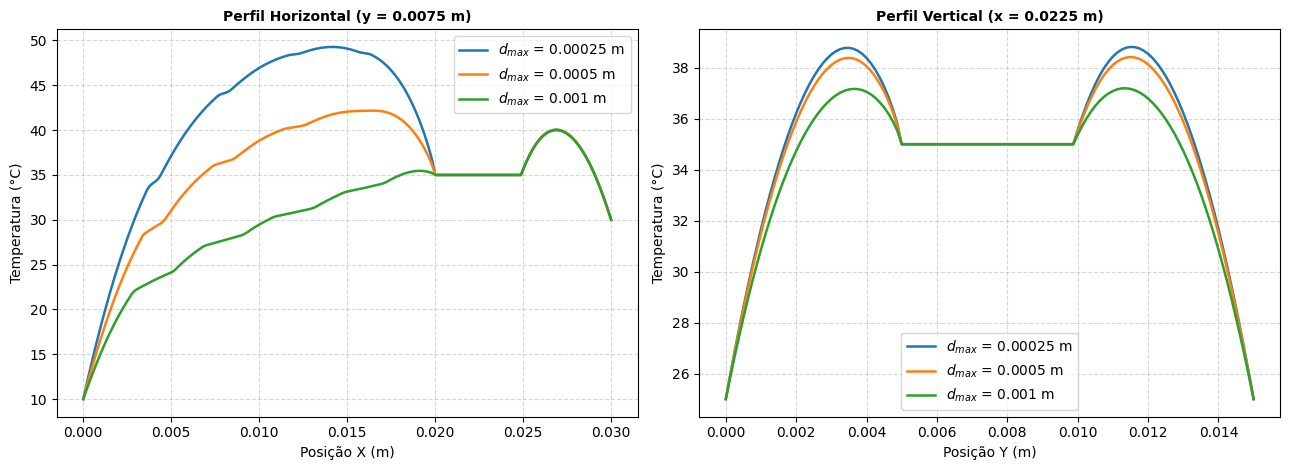


 TABELA COMPARATIVA: TEMPERATURAS MÁXIMAS E TEMPOS DE PROCESSAMENTO COMPUTACIONAL
Malha      | d_max (m)  | T_Min (°C)   | T_Max (°C)   | t_Geom (s) | t_Solv (s) | t_Total (s)
----------------------------------------------------------------------------------------------------
61x31      | 0.00025    | 10.0000      | 49.2606      | 0.0531     | 0.0265     | 0.1425
61x31      | 0.00050    | 10.0000      | 41.2097      | 0.1116     | 0.0246     | 0.1472
61x31      | 0.00100    | 10.0000      | 41.0639      | 0.1461     | 0.0262     | 0.1833
121x61     | 0.00025    | 10.0000      | 48.9349      | 0.1701     | 0.3650     | 0.5714
121x61     | 0.00050    | 10.0000      | 42.1279      | 0.3176     | 0.3844     | 0.7735
121x61     | 0.00100    | 10.0000      | 40.5477      | 0.5293     | 0.3754     | 0.9720
241x121    | 0.00025    | 10.0000      | 49.2785      | 0.6791     | 7.6764     | 8.5505
241x121    | 0.00050    | 10.0000      | 42.1731      | 1.3785     | 5.6413     | 7.8094
241x121   

In [29]:
print("\n" + "="*75)
print("CONDUTIVIDADE MODIFICADA POR PROXIMIDADE")
print("="*75)

# Construção e posicionamento da Rede Hidráulica utilizando suas variáveis globais
Xno_ex5, conec_ex5 = GeraGrafo(levels=3)
Xno_ex5 = Xno_ex5 * 0.001
Xno_ex5[:, 1] += 0.5 * Ly  # Centraliza a rede verticalmente na placa utilizando o Ly global
# Cenários de Varredura Paramétrica solicitados pelo enunciado
lista_malhas_ex5 = [(61, 31), (121, 61), (241, 121)]
lista_dmax_ex5 = [0.00025, 0.0005, 0.001]
resultados_ex5 = []
# Loop de Varredura pelas Malhas Computacionais
for Nx, Ny in lista_malhas_ex5:
    print(f"\n" + "-"*60)
    print(f"Executando Refinamento Espacial: Malha {Nx} x {Ny}")
    print("-"*60)
    
    x_coords = np.linspace(0.0, Lx, Nx)
    y_coords = np.linspace(0.0, Ly, Ny)
    
    # Condições de contorno lineares para as bases inferior e superior (usando Lx global)
    TB = 10.0 + 20.0 * (x_coords / Lx)
    TT = 10.0 + 20.0 * (x_coords / Lx)
    
    # Determinação dos índices para os perfis unidimensionais estratégicos
    j_mid = Ny // 2  # Linha horizontal central (y ≈ 0.0075 m)
    i_secao = int(np.argmin(np.abs(x_coords - xincl)))  # Linha vertical sobre o centro da inclusão global
    perfis_horizontais = {}
    perfis_verticais = {}
    for d_max in lista_dmax_ex5:
        print(f" -> Calculando cenário para d_max = {d_max} m...")
        t_inicio = time.perf_counter()
        # 1. Cálculo das condutividades nas interfaces utilizando as variáveis globais
        t_geom0 = time.perf_counter()
        k_e_grid, k_n_grid = ObterCondutividadeFaces_ViaNos(
            Nx, Ny, Lx, Ly, Xno_ex5, conec_ex5, d_max, k_0
        )
        t_geom = time.perf_counter() - t_geom0
        # 2. Montagem do Sistema Linear Térmico com as variáveis globais do topo do arquivo
        t_mont0 = time.perf_counter()
        A_T, b_T = CriarSistemaSolidoCondutividadeVariavel(
            Nx, Ny, Lx, Ly, k_e_grid, k_n_grid, TL, TR, TB, TT, 
            fonte_calor, R_incl, xincl, yincl, TC
        )
        t_mont = time.perf_counter() - t_mont0
        # 3. Solução do Sistema Linear usando matriz esparsa
        t_sol0 = time.perf_counter()
        T_flat_ex5 = spsolve(sparse.csr_matrix(A_T), b_T)
        t_sol = time.perf_counter() - t_sol0
        
        t_total = time.perf_counter() - t_inicio
        
        # Redimensiona o vetor solução para a matriz 2D (Y, X)
        T_matriz = T_flat_ex5.reshape((Ny, Nx))
        # Extração e salvamento dos perfis unidimensionais
        perfis_horizontais[d_max] = T_matriz[j_mid, :].copy()
        perfis_verticais[d_max] = T_matriz[:, i_secao].copy()
        # Registro das estatísticas e tempos medidos
        resultados_ex5.append({
            "malha": f"{Nx}x{Ny}",
            "d_max": d_max,
            "T_max": np.max(T_flat_ex5),
            "T_min": np.min(T_flat_ex5),
            "t_geometria": t_geom,
            "t_montagem": t_mont,
            "t_solucao": t_sol,
            "t_total": t_total
        })
        # -----------------------------------------------------------------
        # 4. GERAÇÃO DOS MAPAS DE CONTORNO 2D (LIMPO - CORES DOS NÓS VIA LOCAL T)
        # -----------------------------------------------------------------
        fig2d, ax2d = plt.subplots(figsize=(10, 5))
        X_grid, Y_grid = np.meshgrid(x_coords, y_coords)
        
        # Preenchimento de contorno contínuo da temperatura da placa
        cont = ax2d.contourf(X_grid, Y_grid, T_matriz, levels=30, cmap='jet')
        ax2d.contour(X_grid, Y_grid, T_matriz, levels=30, colors='black', linewidths=0.3, alpha=0.5)
        
        # Desenha as linhas dos canais (arestas) em preto bem fino e suave
        for k in range(len(conec_ex5)):
            n1, n2 = int(conec_ex5[k, 0]), int(conec_ex5[k, 1])
            ax2d.plot([Xno_ex5[n1, 0], Xno_ex5[n2, 0]], [Xno_ex5[n1, 1], Xno_ex5[n2, 1]], 
                      color='black', linewidth=0.5, alpha=0.5, zorder=2)
        
        # Interpolação precisa da temperatura do sólido para os nós da rede
        pontos_grade_termica = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
        valores_termicos = T_matriz.ravel()
        T_nos_rede = griddata(pontos_grade_termica, valores_termicos, (Xno_ex5[:, 0], Xno_ex5[:, 1]), method='linear')
        
        # Correção de borda para nós nas extremidades exatas da grade
        if np.any(np.isnan(T_nos_rede)):
            T_nos_rede = griddata(pontos_grade_termica, valores_termicos, (Xno_ex5[:, 0], Xno_ex5[:, 1]), method='nearest')
        # Desenha os nós aplicando de forma dinâmica a escala cromática 'jet' sincronizada com o fundo
        sc = ax2d.scatter(
            Xno_ex5[:, 0], Xno_ex5[:, 1], 
            c=T_nos_rede, 
            cmap='jet', 
            vmin=T_matriz.min(), vmax=T_matriz.max(), 
            s=18, 
            marker='o', 
            edgecolors='black', 
            linewidths=0.5, 
            zorder=3
        )
        
        # Configurações da barra de cores vertical e eixos
        cbar = fig2d.colorbar(cont, ax=ax2d, pad=0.02)
        cbar.set_label('Temperatura (°C)', fontsize=10)
        ax2d.set_title(f"Campo Térmico 2D - Malha {Nx}x{Ny} | $d_{{max}}$ = {d_max} m", fontsize=11, fontweight='bold')
        ax2d.set_xlabel('Posição X (m)')
        ax2d.set_ylabel('Posição Y (m)')
        ax2d.set_aspect('equal')
        plt.tight_layout()
        plt.show()
    # -----------------------------------------------------------------
    # 5. PLOT DOS PERFIS UNIDIMENSIONAIS COMBINADOS (Por nível de malha)
    # -----------------------------------------------------------------
    fig_perf, ax_perf = plt.subplots(1, 2, figsize=(13, 4.8))
    
    # Gráfico Esquerdo: Perfil Horizontal Central
    for d_max in lista_dmax_ex5:
        ax_perf[0].plot(x_coords, perfis_horizontais[d_max], label=f"$d_{{max}}$ = {d_max} m", linewidth=1.8)
    ax_perf[0].set_title(f"Perfil Horizontal (y = {y_coords[j_mid]:.4f} m)", fontsize=10, fontweight='bold')
    ax_perf[0].set_xlabel('Posição X (m)')
    ax_perf[0].set_ylabel('Temperatura (°C)')
    ax_perf[0].grid(True, linestyle='--', alpha=0.5)
    ax_perf[0].legend()
    # Gráfico Direito: Perfil Vertical na Inclusão
    for d_max in lista_dmax_ex5:
        ax_perf[1].plot(y_coords, perfis_verticais[d_max], label=f"$d_{{max}}$ = {d_max} m", linewidth=1.8)
    ax_perf[1].set_title(f"Perfil Vertical (x = {x_coords[i_secao]:.4f} m)", fontsize=10, fontweight='bold')
    ax_perf[1].set_xlabel('Posição Y (m)')
    ax_perf[1].set_ylabel('Temperatura (°C)')
    ax_perf[1].grid(True, linestyle='--', alpha=0.5)
    ax_perf[1].legend()
    
    plt.tight_layout()
    plt.show()
# =========================================================================
# RELATÓRIO DE DESEMPENHO E ANÁLISE PARAMÉTRICA VIA TERMINAL
# =========================================================================
df_ex5 = pd.DataFrame(resultados_ex5)

print("\n" + "="*100)
print(" TABELA COMPARATIVA: TEMPERATURAS MÁXIMAS E TEMPOS DE PROCESSAMENTO COMPUTACIONAL")
print("="*100)
print(f"{'Malha':<10} | {'d_max (m)':<10} | {'T_Min (°C)':<12} | {'T_Max (°C)':<12} | {'t_Geom (s)':<10} | {'t_Solv (s)':<10} | {'t_Total (s)'}")
print("-" * 100)
for r in resultados_ex5:
    print(f"{r['malha']:<10} | {r['d_max']:<10.5f} | {r['T_min']:<12.4f} | {r['T_max']:<12.4f} | "
          f"{r['t_geometria']:<10.4f} | {r['t_solucao']:<10.4f} | {r['t_total']:.4f}")
print("-" * 100)



---
## 8. Influência no Termo Fonte e Sumidouro (Exercício 2, Seção 4.3.2)

Modelagem de sumidouros ou fontes térmicas espaciais distribuídas. Ao invés de impor termos de troca pontuais isolados, distribui-se a carga de forma radiativa contínua modelada por uma função Gaussiana atenuada em relação à distância do canal $d$:

$$S_p(x,y) = S_0 \cdot \exp\left(-\frac{d^2}{2\sigma^2}\right)$$

Onde o desvio padrão espacial dita o raio de influência da rede ($\sigma = d_{\text{max}}/2$). Avaliam-se duas configurações físicas estruturadas:
1. **Injeção Homogênea:** $I_j = 1$ para todas as arestas da rede. 
2. **Injeção Heterogênea:** $I_j = 100$ para as arestas pertencentes ao alinhamento central (espinha principal) e $I_j = 0.1$ para as demais arestas remanescentes.


O sistema varia a intensidade base da fonte $S_0$ em 6 níveis diferentes:
$$S_0 = [10^5, \; 5\times10^5, \; 10^6, \; -10^5, \; -5\times10^5, \; -10^6] \text{ W}\cdot\text{m}^{-3}$$


 EXERCÍCIO 2 (Secção 4.3.2) - INFLUÊNCIA NO TERMO FONTE
Função de grafo encontrada: GeraGrafo
Rede hidráulica carregada com sucesso.
Xno.shape = (224, 2)
conec.shape = (327, 2)
x mínimo/máximo = 0.0 0.02
y mínimo/máximo = 0.001767879439820332 0.013232120560179667
Arestas na espinha central detectadas: 5

Calculando cenários térmicos...
S0 = 1.0e+05 | fonte min = 0.000e+00 | fonte max = 8.624e+05
S0 = 1.0e+05 | fonte min = 0.000e+00 | fonte max = 2.004e+07
S0 = 5.0e+05 | fonte min = 0.000e+00 | fonte max = 4.312e+06
S0 = 5.0e+05 | fonte min = 0.000e+00 | fonte max = 1.002e+08
S0 = 1.0e+06 | fonte min = 0.000e+00 | fonte max = 8.624e+06
S0 = 1.0e+06 | fonte min = 0.000e+00 | fonte max = 2.004e+08
S0 = -1.0e+05 | fonte min = -8.624e+05 | fonte max = -0.000e+00
S0 = -1.0e+05 | fonte min = -2.004e+07 | fonte max = -0.000e+00
S0 = -5.0e+05 | fonte min = -4.312e+06 | fonte max = -0.000e+00
S0 = -5.0e+05 | fonte min = -1.002e+08 | fonte max = -0.000e+00
S0 = -1.0e+06 | fonte min = -8.624e+06 

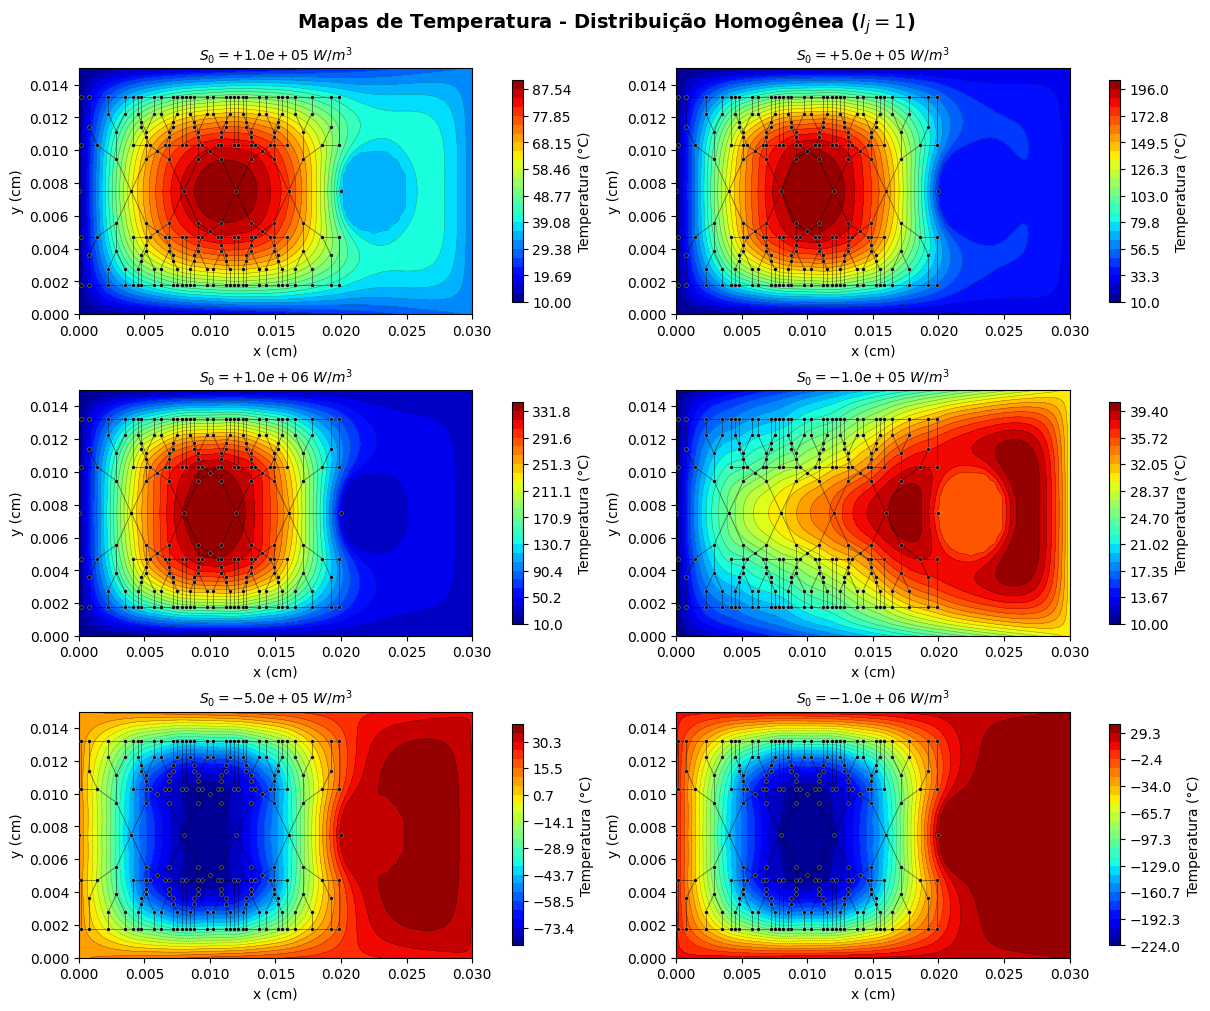

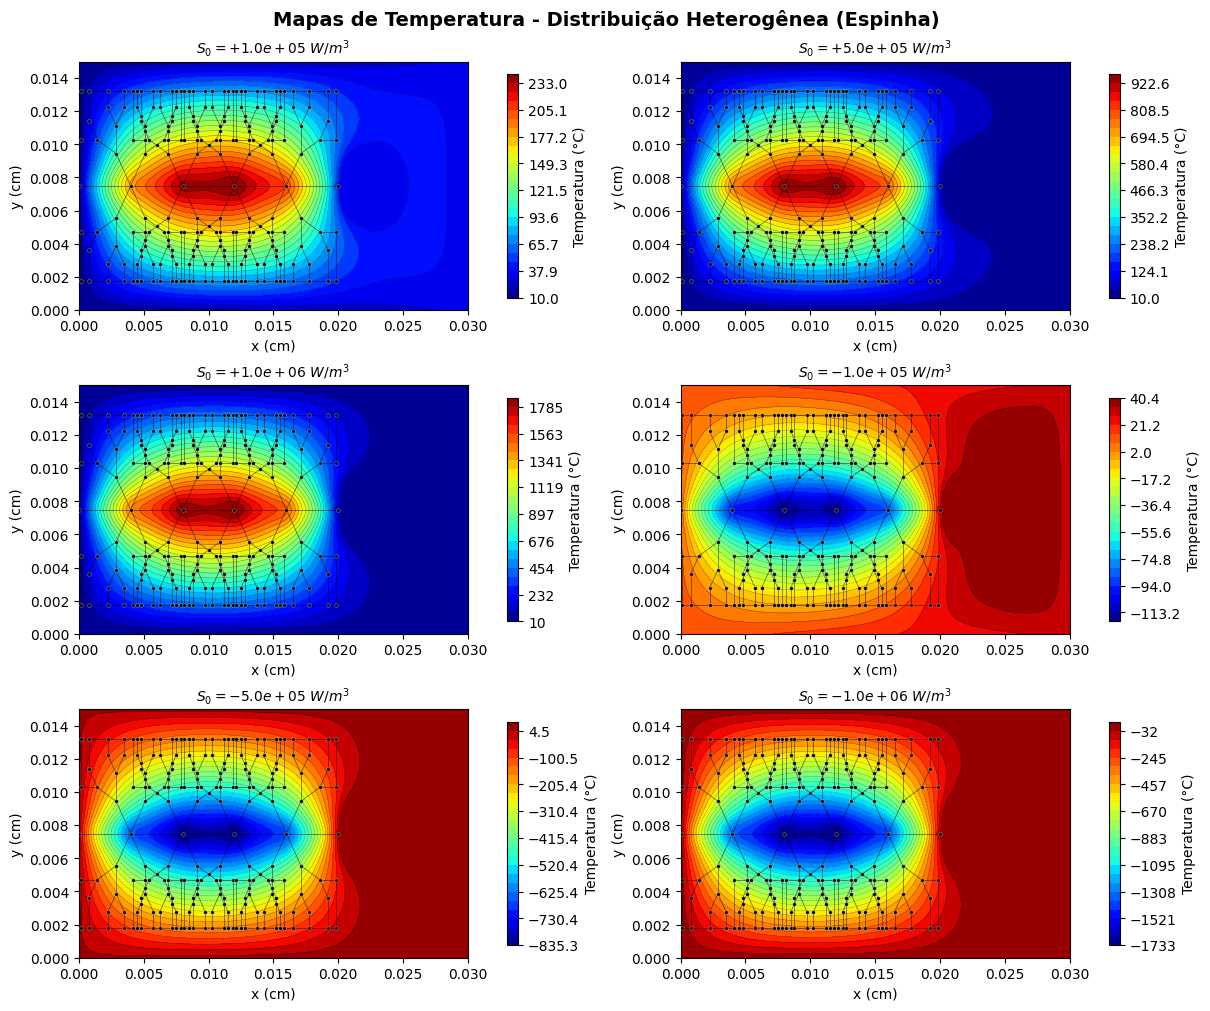


COMPARAÇÃO DOS VALORES MÁXIMOS DE TEMPERATURA
S0           | Tmin Homo (°C)     | Tmax Homo (°C)     | Tmin Hete (°C)     | Tmax Hete (°C)    
---------------------------------------------------------------------------------------------------------
1e+05        | 10.0000            | 90.7694            | 10.0000            | 242.2453          
5e+05        | 10.0000            | 203.7864           | 10.0000            | 960.6327          
1e+06        | 10.0000            | 345.1953           | 10.0000            | 1858.6170         
-1e+05       | 10.0000            | 40.6243            | -119.5986          | 40.3759           
-5e+05       | -83.2424           | 40.2195            | -835.3359          | 39.5191           
-1e+06       | -223.9796          | 39.8561            | -1733.3202         | 38.7619           


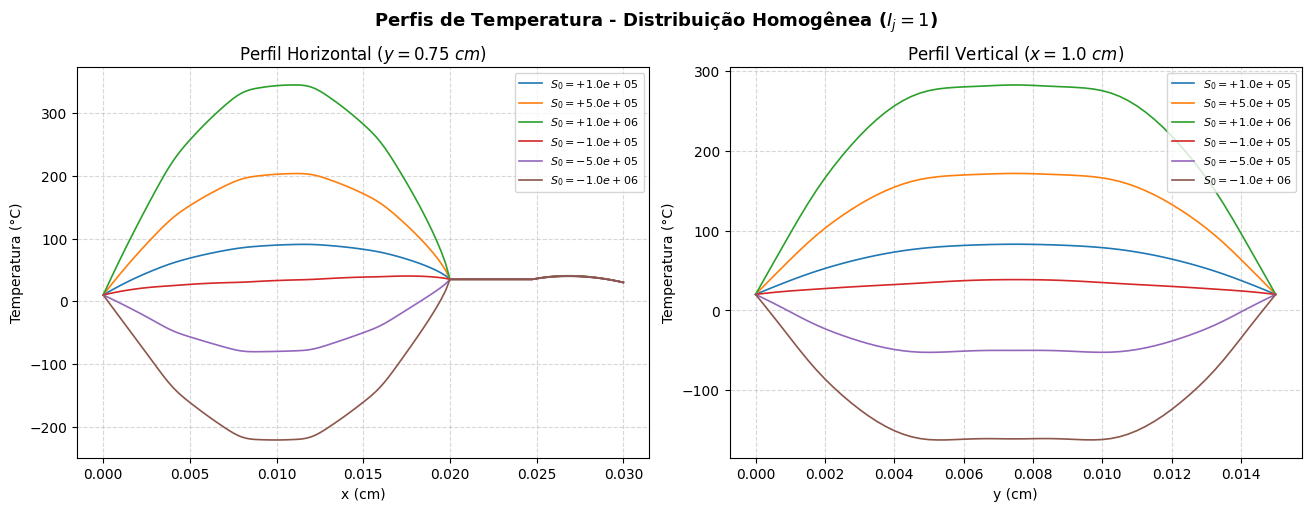

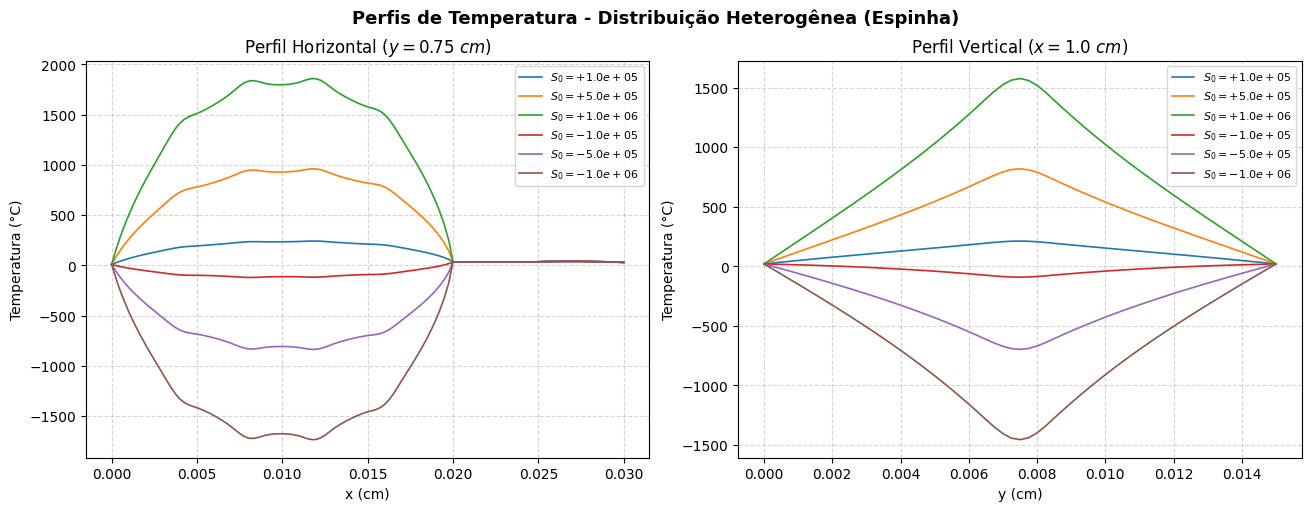

In [14]:
print("\n" + "="*54)
print(" EXERCÍCIO 2 (Secção 4.3.2) - INFLUÊNCIA NO TERMO FONTE")
print("="*54)

# Parâmetros Físicos Locais do Exercício
Lx_cap4 = 0.03
Ly_cap4 = 0.015
k0_cap4 = 0.25
fonte_nominal = 5e5
TR_cap4 = 30.0

cilindro_cap4 = {
    'R': 0.0025,
    'cx': 0.0225,
    'cy': 0.0075,
    'Tc': 35.0
}

# Passando o escopo do bloco atual (globals()) para que ele possa capturar
# as funções 'GeraGrafo' ou 'Xno'/'conec' definidas nas células/módulos anteriores
Xno, conec = carregar_rede_hidraulica(
    levels=3,
    spine_length=6,
    Lx=Lx_cap4,
    Ly=Ly_cap4,
    globals_dict=globals()
)

print("Rede hidráulica carregada com sucesso.")
print("Xno.shape =", Xno.shape)
print("conec.shape =", conec.shape)
print("x mínimo/máximo =", np.min(Xno[:, 0]), np.max(Xno[:, 0]))
print("y mínimo/máximo =", np.min(Xno[:, 1]), np.max(Xno[:, 1]))

# Identificação das Arestas da Espinha Central
y_center = 0.5 * Ly_cap4
spine_edges = []
tol_spine = 1e-4

for k in range(conec.shape[0]):
    n1, n2 = conec[k]
    y1 = Xno[n1, 1]
    y2 = Xno[n2, 1]

    if abs(y1 - y_center) < tol_spine and abs(y2 - y_center) < tol_spine:
        spine_edges.append(k)

if len(spine_edges) == 0:
    print("[AVISO] Nenhuma aresta da espinha central foi detectada.")
else:
    print(f"Arestas na espinha central detectadas: {len(spine_edges)}")

nc = conec.shape[0]
I_j_homogeneo = np.ones(nc)
I_j_heterogeneo = np.full(nc, 0.1)
I_j_heterogeneo[spine_edges] = 100.0

# Execução das Malhas e Cenários
Nx_m = 121
Ny_m = 61
d_max_f = 0.001

S0_list = [1e5, 5e5, 1e6, -1e5, -5e5, -1e6]

x_grid = np.linspace(0.0, Lx_cap4, Nx_m)
y_grid = np.linspace(0.0, Ly_cap4, Ny_m)
X, Y = np.meshgrid(x_grid, y_grid)

resultados_ex2 = []
print("\nCalculando cenários térmicos...")

for S0 in S0_list:
    fonte_homo = calc_campo_fonte(Nx_m, Ny_m, Lx_cap4, Ly_cap4, Xno, conec, S0, d_max_f, I_j_homogeneo)
    T_homo = SolveSystem_FonteEspacial(Nx_m, Ny_m, Lx_cap4, Ly_cap4, k0_cap4, fonte_nominal, cilindro_cap4, TR_cap4, fonte_homo)

    fonte_hete = calc_campo_fonte(Nx_m, Ny_m, Lx_cap4, Ly_cap4, Xno, conec, S0, d_max_f, I_j_heterogeneo)
    T_hete = SolveSystem_FonteEspacial(Nx_m, Ny_m, Lx_cap4, Ly_cap4, k0_cap4, fonte_nominal, cilindro_cap4, TR_cap4, fonte_hete)

    resultados_ex2.append({
        'S0': S0,
        'fonte_homo': fonte_homo,
        'fonte_hete': fonte_hete,
        'T_homo': T_homo,
        'T_hete': T_hete,
        'Tmin_homo': np.min(T_homo),
        'Tmax_homo': np.max(T_homo),
        'Tmin_hete': np.min(T_hete),
        'Tmax_hete': np.max(T_hete)
    })

# ==============================================================================
# 1. MAPAS DE TEMPERATURA - DISTRIBUIÇÃO HOMOGÊNEA (Matriz 3x2)
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle("Mapas de Temperatura - Distribuição Homogênea ($I_j = 1$)", fontsize=14, fontweight='bold')

for i, item in enumerate(resultados_ex2):
    linha = i // 2
    col = i % 2
    ax = axes[linha, col]
    
    S0 = item['S0']
    Z = item['T_homo']
    
    vmin, vmax, levels = obter_limites_e_niveis_individuais(Z, n_levels=26)
    cf = ax.contourf(X, Y, Z, levels=levels, cmap='jet', vmin=vmin, vmax=vmax, zorder=1)
    ax.contour(X, Y, Z, levels=levels, colors='black', linewidths=0.3, alpha=0.5, vmin=vmin, vmax=vmax, zorder=1)
    plotar_rede_sobre_ax(ax, Xno, conec)
    
    cbar = fig.colorbar(cf, ax=ax, shrink=0.9)
    cbar.set_label('Temperatura (°C)')
    
    ax.set_title(rf"$S_0 = {S0:+.1e}\ W/m^3$", fontsize=10)
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
    ax.set_xlim(0.0, Lx_cap4)
    ax.set_ylim(0.0, Ly_cap4)

plt.show()


# ==============================================================================
# 2. MAPAS DE TEMPERATURA - DISTRIBUIÇÃO HETEROGÊNEA (Matriz 3x2)
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle("Mapas de Temperatura - Distribuição Heterogênea (Espinha)", fontsize=14, fontweight='bold')

for i, item in enumerate(resultados_ex2):
    linha = i // 2
    col = i % 2
    ax = axes[linha, col]
    
    S0 = item['S0']
    Z = item['T_hete']
    
    vmin, vmax, levels = obter_limites_e_niveis_individuais(Z, n_levels=26)
    cf = ax.contourf(X, Y, Z, levels=levels, cmap='jet', vmin=vmin, vmax=vmax, zorder=1)
    ax.contour(X, Y, Z, levels=levels, colors='black', linewidths=0.3, alpha=0.5, vmin=vmin, vmax=vmax, zorder=1)
    plotar_rede_sobre_ax(ax, Xno, conec)
    
    cbar = fig.colorbar(cf, ax=ax, shrink=0.9)
    cbar.set_label('Temperatura (°C)')
    
    ax.set_title(rf"$S_0 = {S0:+.1e}\ W/m^3$", fontsize=10)
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
    ax.set_xlim(0.0, Lx_cap4)
    ax.set_ylim(0.0, Ly_cap4)

plt.show()


# ==============================================================================
# 3. TABELA DE COMPARAÇÃO NO TERMINAL (Inalterada)
# ==============================================================================
print("\n" + "=" * 105)
print("COMPARAÇÃO DOS VALORES MÁXIMOS DE TEMPERATURA")
print("=" * 105)
print(f"{'S0':<12} | {'Tmin Homo (°C)':<18} | {'Tmax Homo (°C)':<18} | {'Tmin Hete (°C)':<18} | {'Tmax Hete (°C)':<18}")
print("-" * 105)
for item in resultados_ex2:
    print(f"{item['S0']:<12.0e} | {item['Tmin_homo']:<18.4f} | {item['Tmax_homo']:<18.4f} | {item['Tmin_hete']:<18.4f} | {item['Tmax_hete']:<18.4f}")
print("=" * 105)


# ==============================================================================
# 4. PERFIS DE TEMPERATURA — DISTRIBUIÇÃO HOMOGÊNEA (Curvas Agrupadas)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle("Perfis de Temperatura - Distribuição Homogênea ($I_j = 1$)", fontsize=13, fontweight='bold')

mid_y, mid_x = Ny_m // 2, Nx_m // 2

# Loop para plotar todas as curvas de S0 no mesmo gráfico
for item in resultados_ex2:
    S0 = item['S0']
    lbl = f"$S_0 = {S0:+.1e}$"
    
    # Horizontal (fixo em y)
    axes[0].plot(x_grid, item['T_homo'][mid_y, :], label=lbl, linewidth=1.2)
    # Vertical (fixo em x)
    axes[1].plot(y_grid, item['T_homo'][:, mid_x], label=lbl, linewidth=1.2)

# Customização do gráfico Horizontal
axes[0].set_title(r"Perfil Horizontal ($y = 0.75\ cm$)")
axes[0].set_xlabel("x (cm)")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=8, loc='best')

# Customização do gráfico Vertical
axes[1].set_title(r"Perfil Vertical ($x = 1.0\ cm$)")
axes[1].set_xlabel("y (cm)")
axes[1].set_ylabel("Temperatura (°C)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=8, loc='best')

plt.show()


# ==============================================================================
# 5. PERFIS DE TEMPERATURA — DISTRIBUIÇÃO HETEROGÊNEA (Curvas Agrupadas)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle("Perfis de Temperatura - Distribuição Heterogênea (Espinha)", fontsize=13, fontweight='bold')

for item in resultados_ex2:
    S0 = item['S0']
    lbl = f"$S_0 = {S0:+.1e}$"
    
    # Horizontal (fixo em y)
    axes[0].plot(x_grid, item['T_hete'][mid_y, :], label=lbl, linewidth=1.2)
    # Vertical (fixo em x)
    axes[1].plot(y_grid, item['T_hete'][:, mid_x], label=lbl, linewidth=1.2)

# Customização do gráfico Horizontal
axes[0].set_title(r"Perfil Horizontal ($y = 0.75\ cm$)")
axes[0].set_xlabel("x (cm)")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=8, loc='best')

# Customização do gráfico Vertical
axes[1].set_title(r"Perfil Vertical ($x = 1.0\ cm$)")
axes[1].set_xlabel("y (cm)")
axes[1].set_ylabel("Temperatura (°C)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=8, loc='best')

plt.show()
